# MRPC Batch Size Experiment Analysis

MRPC 실험 로그(`exp_outputs/mrpc/...`)를 불러와 batch size에 따른 학습/검증 추이를 시각화합니다.
- step 단위 학습 손실과 추세선, epoch 경계선 표시
- epoch 단위 검증 손실/정확도/F1 비교
- batch size별 최종 검증 지표 요약 표 및 그래프

## 1. Load Experiment Metadata
GaLore(`exp_outputs/mrpc_base`), baseline full fine-tuning(`exp_outputs/mrpc_FT`), 그리고 개선된 single-projection 변형(`exp_outputs/mrpc2`) 루트를 동시에 스캔해 batch size별 폴더를 열거하고 `all_results.json` 정보를 하나의 표로 정리합니다.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="colorblind")

METHOD_ORDER = ["Single-Projection", "GaLore", "Full-FT"]
METHOD_STYLE = {
    "Single-Projection": {"alpha": 1.0, "linewidth": 2.6, "marker": "o"},
    "GaLore": {"alpha": 0.85, "linewidth": 2.0, "marker": "s"},
    "Full-FT": {"alpha": 0.7, "linewidth": 1.3, "marker": "^"},
}

EXPERIMENT_SPECS: List[Tuple[str, List[str]]] = [
    ("GaLore", [
        "exp_outputs/mrpc_base",
        "../exp_outputs/mrpc_base",
        "../../exp_outputs/mrpc_base",
    ]),
    ("Full-FT", [
        "exp_outputs/mrpc_FT",
        "../exp_outputs/mrpc_FT",
        "../../exp_outputs/mrpc_FT",
    ]),
    ("Single-Projection", [
        "exp_outputs/mrpc2",
        "../exp_outputs/mrpc2",
        "../../exp_outputs/mrpc2",
    ]),
 ]

def resolve_experiment_roots(
    specs: Iterable[Tuple[str, Iterable[str]]]
) -> List[Tuple[str, Path]]:
    resolved: List[Tuple[str, Path]] = []
    for method, candidates in specs:
        found: Optional[Path] = None
        for candidate in candidates:
            candidate_path = Path(candidate)
            if candidate_path.exists():
                found = candidate_path.resolve()
                break
        if found:
            resolved.append((method, found))
        else:
            checked = ", ".join(str(Path(c).resolve()) for c in candidates)
            print(f"Warning: no runs found for {method}; checked {checked}")
    if not resolved:
        raise FileNotFoundError("Could not locate any MRPC experiments. Update EXPERIMENT_SPECS.")
    return resolved

def parse_batch_size(folder_name: str) -> int:
    for part in folder_name.split("_"):
        if part.startswith("bs"):
            try:
                return int(part[2:])
            except ValueError:
                continue
    raise ValueError(f"Unable to parse batch size from {folder_name}")

def load_json(path: Path) -> Dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def collect_run_specs(experiment_roots: Iterable[Tuple[str, Path]]):
    run_specs: List[Dict[str, Any]] = []
    for method, root in experiment_roots:
        bs_dirs = sorted(
            [d for d in root.iterdir() if d.is_dir() and d.name.startswith("bs")],
            key=lambda d: parse_batch_size(d.name),
        )
        if not bs_dirs:
            print(f"Warning: {method} root {root} has no batch-size folders.")
            continue
        for folder in bs_dirs:
            run_specs.append(
                {
                    "method": method,
                    "batch_size": parse_batch_size(folder.name),
                    "folder": folder,
                }
            )
    if not run_specs:
        raise ValueError("No batch-size runs found under the configured experiment roots.")
    return run_specs

def build_method_palette(methods: List[str]) -> Dict[str, tuple]:
    ordered_methods = [m for m in METHOD_ORDER if m in methods] + [
        m for m in methods if m not in METHOD_ORDER
]
    palette = sns.color_palette("Set2", n_colors=max(len(ordered_methods), 3))
    return {method: palette[idx] for idx, method in enumerate(ordered_methods)}

def get_method_style(method: str) -> Dict[str, float]:
    base = {"alpha": 0.7, "linewidth": 1.8, "marker": "o"}
    base.update(METHOD_STYLE.get(method, {}))
    return base

experiment_roots = resolve_experiment_roots(EXPERIMENT_SPECS)
for method, root in experiment_roots:
    print(f"{method} root: {root}")

run_specs = collect_run_specs(experiment_roots)
method_map: Dict[str, List[int]] = {}
for spec in run_specs:
    method_map.setdefault(spec["method"], []).append(spec["batch_size"])
for method, batches in method_map.items():
    uniq_batches = sorted(set(batches))
    print(
        f"{method}: found {len(uniq_batches)} batch-size runs -> {uniq_batches}",
    )

summary_records: List[Dict[str, Any]] = []
for spec in run_specs:
    folder = spec["folder"]
    results_path = folder / "all_results.json"
    metrics = load_json(results_path) if results_path.exists() else {}
    summary_records.append(
        {
            "method": spec["method"],
            "batch_size": spec["batch_size"],
            "folder": folder.name,
            "eval_loss": metrics.get("eval_loss"),
            "eval_accuracy": metrics.get("eval_accuracy"),
            "eval_f1": metrics.get("eval_f1"),
        }
    )

summary_df = (
    pd.DataFrame(summary_records)
    .sort_values(["method", "batch_size"])
    .reset_index(drop=True)
)
summary_df

GaLore root: /workspace/joel/GaLore_YOWHAJNG/exp_outputs/mrpc_base
Full-FT root: /workspace/joel/GaLore_YOWHAJNG/exp_outputs/mrpc_FT
Single-Projection root: /workspace/joel/GaLore_YOWHAJNG/exp_outputs/mrpc2
GaLore: found 5 batch-size runs -> [1, 8, 16, 32, 128]
Full-FT: found 5 batch-size runs -> [1, 8, 16, 32, 128]
Single-Projection: found 5 batch-size runs -> [1, 8, 16, 32, 128]


,method,batch_size,folder,eval_loss,eval_accuracy,eval_f1
0,Full-FT,1,bs1_acc1_epochs30,None,NaN,NaN
1,Full-FT,1,bs1_acc1_epochs30__1,None,0.683824,0.812227
2,Full-FT,8,bs8_acc1_epochs30,None,NaN,NaN
3,Full-FT,8,bs8_acc1_epochs30__1,None,0.875000,0.912220
4,Full-FT,16,bs16_acc1_epochs30,None,NaN,NaN
5,Full-FT,16,bs16_acc1_epochs30__1,None,0.872549,0.910035
6,Full-FT,32,bs32_acc1_epochs30,None,NaN,NaN
7,Full-FT,32,bs32_acc1_epochs30__1,None,0.901961,0.929078
8,Full-FT,128,bs128_acc1_epochs30,None,NaN,NaN
9,Full-FT,128,bs128_acc1_epochs30__1,None,0.884804,0.917976


## 2. Parse Training Metrics per Batch Size
`train_step_metrics*.jsonl` 파일을 읽어 step·epoch·loss 정보를 데이터프레임으로 정리하고 추세선을 계산합니다.

In [2]:
def load_jsonl(path: Path) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return records

def first_file(folder: Path, pattern: str) -> Optional[Path]:
    matches = sorted(folder.glob(pattern))
    return matches[0] if matches else None

train_records: List[Dict[str, Any]] = []
for spec in run_specs:
    bs = spec["batch_size"]
    method = spec["method"]
    train_file = first_file(spec["folder"], "train_step_metrics*.jsonl")
    if not train_file:
        continue
    for row in load_jsonl(train_file):
        train_records.append(
            {
                "method": method,
                "batch_size": bs,
                "step": int(row.get("step", 0)),
                "epoch": float(row.get("epoch", 0.0)),
                "train_loss": float(row.get("train_loss", np.nan)),
            }
        )

train_df = (
    pd.DataFrame(train_records)
    .sort_values(["method", "batch_size", "step"])
    .reset_index(drop=True)
)

group_cols = ["method", "batch_size"]
if not train_df.empty:
    def ewm_by_length(series: pd.Series) -> pd.Series:
        span = max(25, int(len(series) * 0.02))
        return series.ewm(span=span, min_periods=1).mean()

    train_df["train_loss_smooth"] = (
        train_df.groupby(group_cols)["train_loss"].transform(ewm_by_length)
    )
    train_epoch_markers = (
        train_df.assign(epoch_floor=lambda df: df["epoch"].astype(int))
        .groupby(group_cols + ["epoch_floor"])["step"].min()
        .reset_index()
        .rename(columns={"epoch_floor": "epoch"})
    )
    display(train_df.head())
    method_count = train_df["method"].nunique()
    print(
        f"Loaded {len(train_df):,} training steps across {method_count} methods and {train_df['batch_size'].nunique()} batch sizes.",
    )
else:
    train_epoch_markers = pd.DataFrame(columns=["method", "batch_size", "epoch", "step"])
    print("No training step metrics found.")

,method,batch_size,step,epoch,train_loss,train_loss_smooth
0,Full-FT,1,1,0.000273,0.637924,0.637924
1,Full-FT,1,2,0.000545,0.582363,0.610131
2,Full-FT,1,3,0.000818,0.536808,0.585668
3,Full-FT,1,4,0.001091,0.474271,0.557781
4,Full-FT,1,5,0.001363,0.476977,0.541590


Loaded 405,090 training steps across 3 methods and 5 batch sizes.


## 3. Plot Step-wise Train Loss with Trendline and Epoch Markers
batch size별로 step에 따라 학습 손실 곡선을 그리고, 지수 이동 평균(EWMA) 추세선과 epoch 경계선을 함께 표시합니다.

### Training Loss Stability (Last 10% Steps)
마지막 10% 학습 스텝 구간의 `train_loss` 표준편차를 계산해 batch size/방법별 안정성을 비교합니다. 값이 낮을수록 수렴 과정이 덜 흔들립니다.

In [12]:
if train_df.empty:
    print("Training dataframe is empty; cannot compute stability metrics.")
else:
    def tail_std(df: pd.DataFrame) -> pd.Series:
        tail_len = max(1, math.ceil(len(df) * 0.10))
        tail_slice = df.sort_values("step").tail(tail_len)
        return pd.Series(
            {
                "loss_std_last_10pct": float(tail_slice["train_loss"].std(ddof=0)),
                "steps_considered": tail_len,
            }
        )

    stability_df = (
        train_df.groupby(["method", "batch_size"])
        .apply(tail_std)
        .reset_index()
        .sort_values(["loss_std_last_10pct", "method", "batch_size"])
    )

    display(
        stability_df
        .assign(
            loss_std_last_10pct=lambda df: df["loss_std_last_10pct"].astype(float),
        )
        .style.format(
            {
                "loss_std_last_10pct": "{:.4f}",
            }
        ).set_caption("Training loss std dev over last 10% steps (lower = more stable)")
    )

,method,batch_size,loss_std_last_10pct,steps_considered
4,Full-FT,128,0.0035,87.000000
3,Full-FT,32,0.0039,345.000000
2,Full-FT,16,0.0059,690.000000
8,GaLore,32,0.0279,345.000000
12,Single-Projection,16,0.0294,690.000000
1,Full-FT,8,0.0313,1377.000000
9,GaLore,128,0.0329,87.000000
13,Single-Projection,32,0.0341,345.000000
14,Single-Projection,128,0.0413,87.000000
7,GaLore,16,0.0446,690.000000


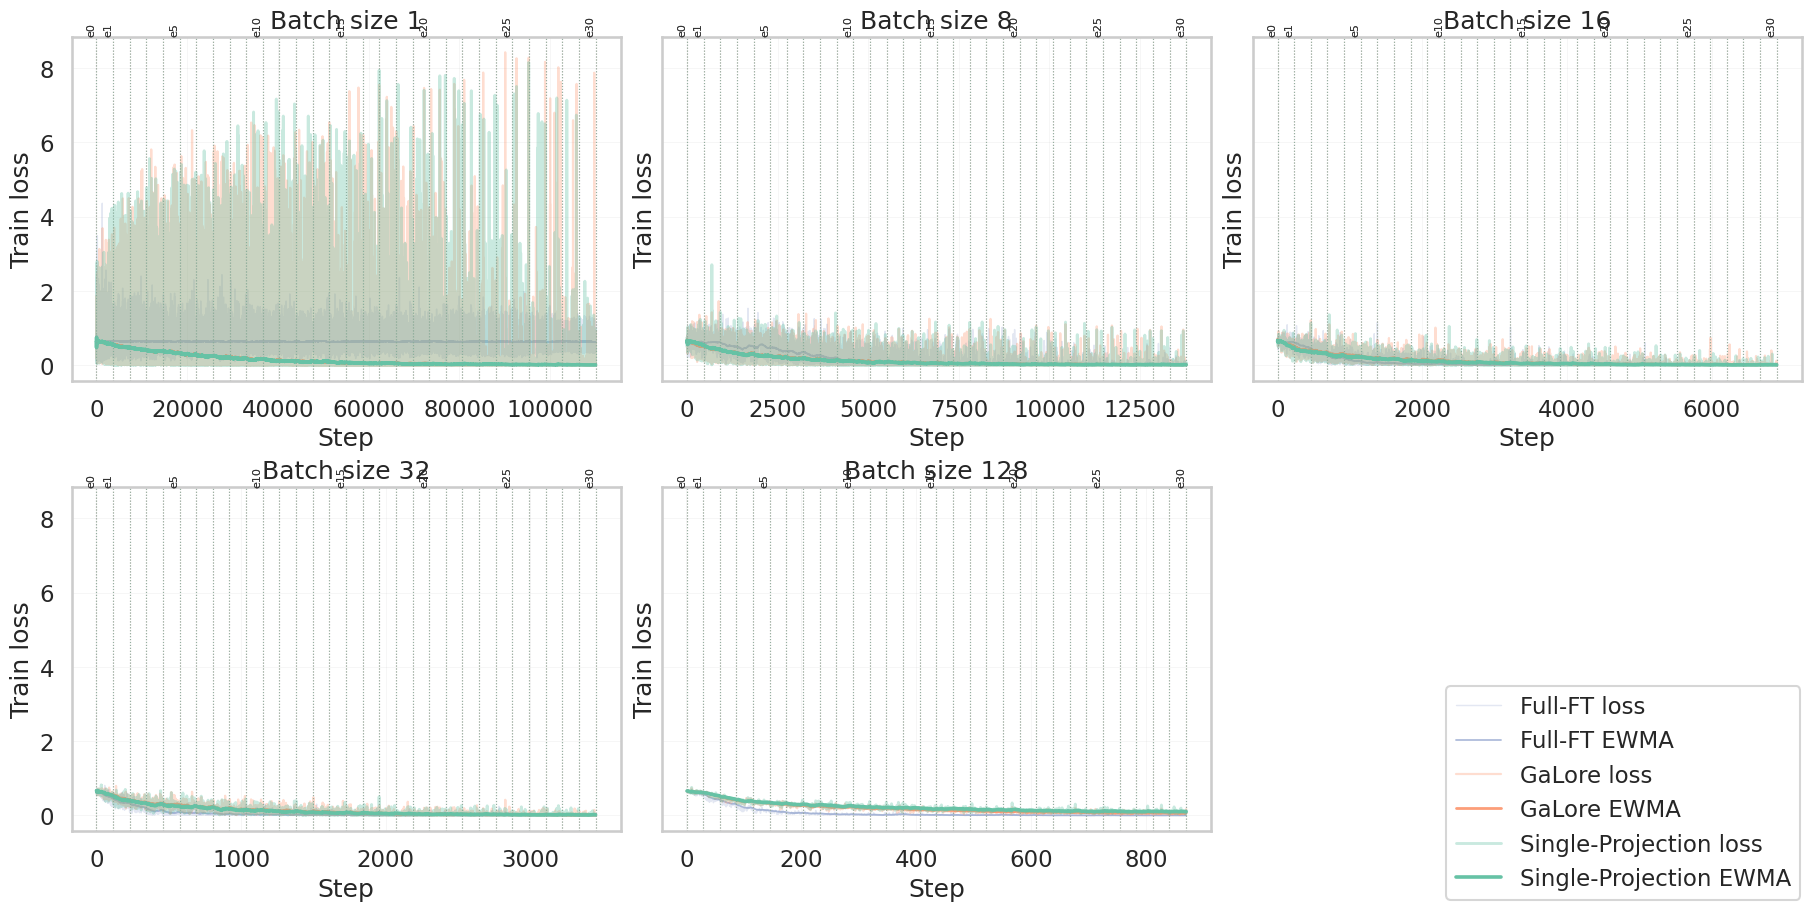

In [3]:
if train_df.empty:
    print("Training dataframe is empty; nothing to plot.")
else:
    unique_bs = sorted(train_df["batch_size"].unique())
    methods = sorted(train_df["method"].unique())
    method_palette = build_method_palette(methods)

    n_cols = 3
    n_rows = math.ceil(len(unique_bs) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows),
        sharey=True,
        constrained_layout=True,
    )
    axes = axes.flatten()

    seen_labels: set[str] = set()
    for ax, bs in zip(axes, unique_bs):
        subset = train_df[train_df["batch_size"] == bs]
        markers = train_epoch_markers[train_epoch_markers["batch_size"] == bs]
        if subset.empty:
            ax.axis("off")
            continue

        for method in methods:
            method_subset = subset[subset["method"] == method]
            if method_subset.empty:
                continue
            color = method_palette[method]
            style = get_method_style(method)

            raw_label = f"{method} loss"
            label_raw = raw_label if raw_label not in seen_labels else None
            if label_raw:
                seen_labels.add(raw_label)
            ax.plot(
                method_subset["step"],
                method_subset["train_loss"],
                color=color,
                alpha=style["alpha"] * 0.35,
                linewidth=style["linewidth"] * 0.8,
                label=label_raw,
            )

            smooth_label = f"{method} EWMA"
            label_smooth = smooth_label if smooth_label not in seen_labels else None
            if label_smooth:
                seen_labels.add(smooth_label)
            ax.plot(
                method_subset["step"],
                method_subset["train_loss_smooth"],
                color=color,
                linewidth=style["linewidth"],
                alpha=style["alpha"],
                label=label_smooth,
            )

            method_markers = markers[markers["method"] == method]
            for _, marker in method_markers.iterrows():
                marker_color = sns.desaturate(color, 0.6)
                ax.axvline(
                    marker["step"],
                    color=marker_color,
                    linestyle=":",
                    linewidth=0.8,
                    alpha=style["alpha"] * 0.7,
                )

        ymax = ax.get_ylim()[1]
        for _, marker in markers.iterrows():
            if marker["epoch"] in {0, 1} or marker["epoch"] % 5 == 0:
                ax.text(
                    marker["step"],
                    ymax,
                    f"e{int(marker['epoch'])}",
                    rotation=90,
                    va="bottom",
                    ha="right",
                    fontsize=8,
                    alpha=0.6,
                )

        ax.set_title(f"Batch size {bs}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Train loss")
        ax.grid(True, linewidth=0.4, alpha=0.3)

    for ax in axes[len(unique_bs):]:
        ax.axis("off")

    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for handle, label in zip(h, l):
            if label not in labels:
                handles.append(handle)
                labels.append(label)
    if handles:
        fig.legend(handles, labels, loc="lower right")
    plt.show()

## 4. Plot Validation Metrics per Epoch
`eval_epoch_metrics*.jsonl`을 읽어 epoch 대비 손실·정확도·F1 추이를 한 번에 비교합니다.

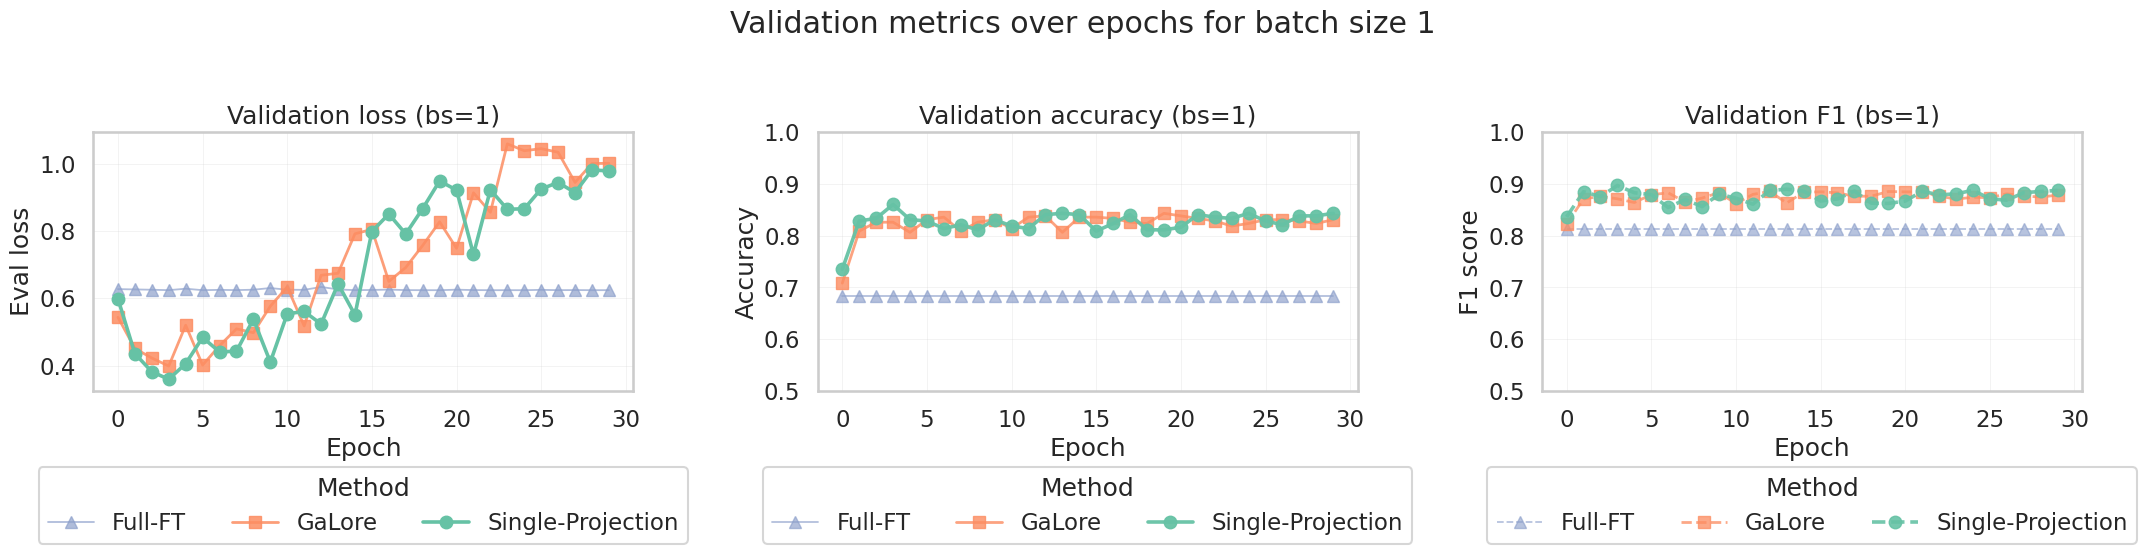

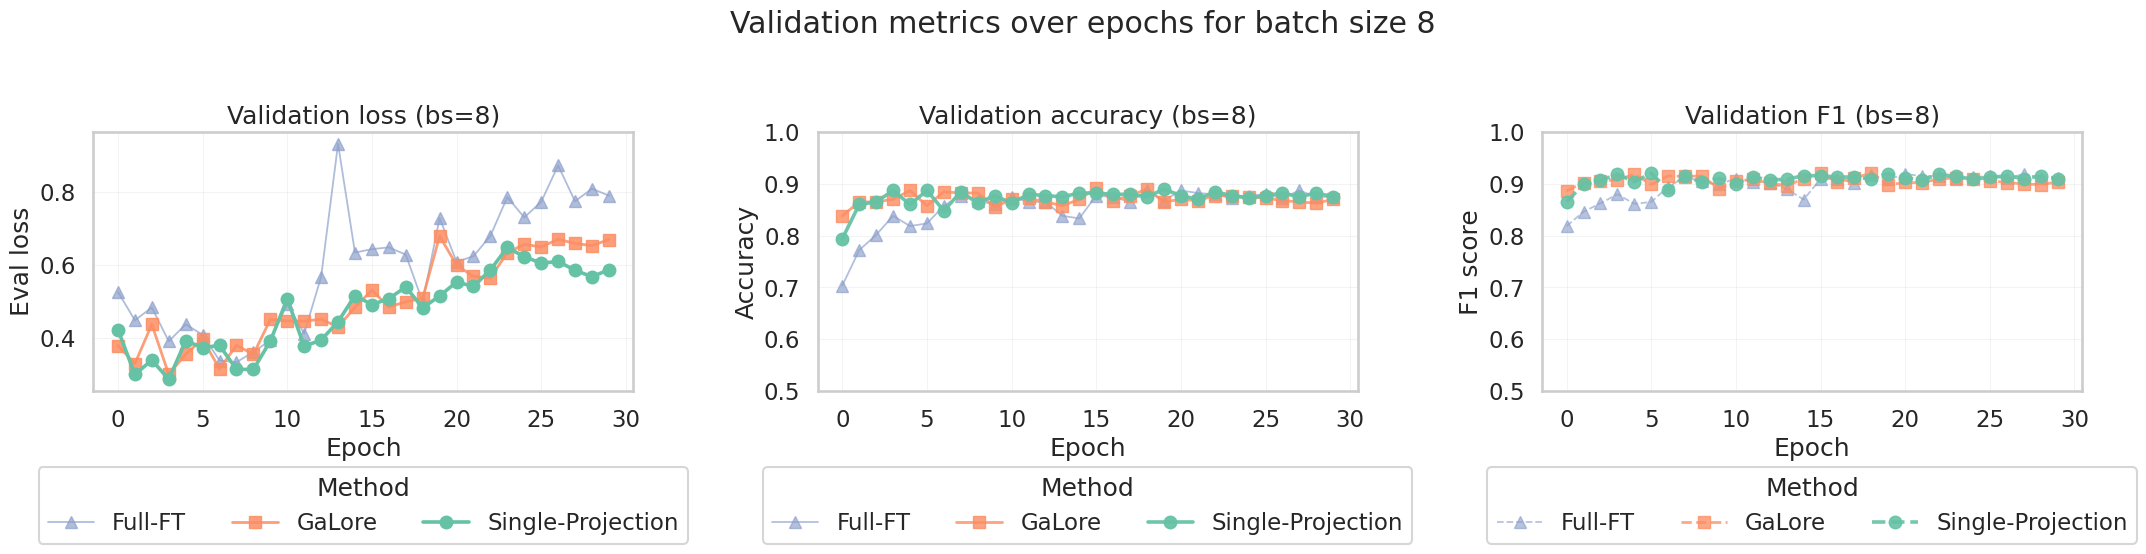

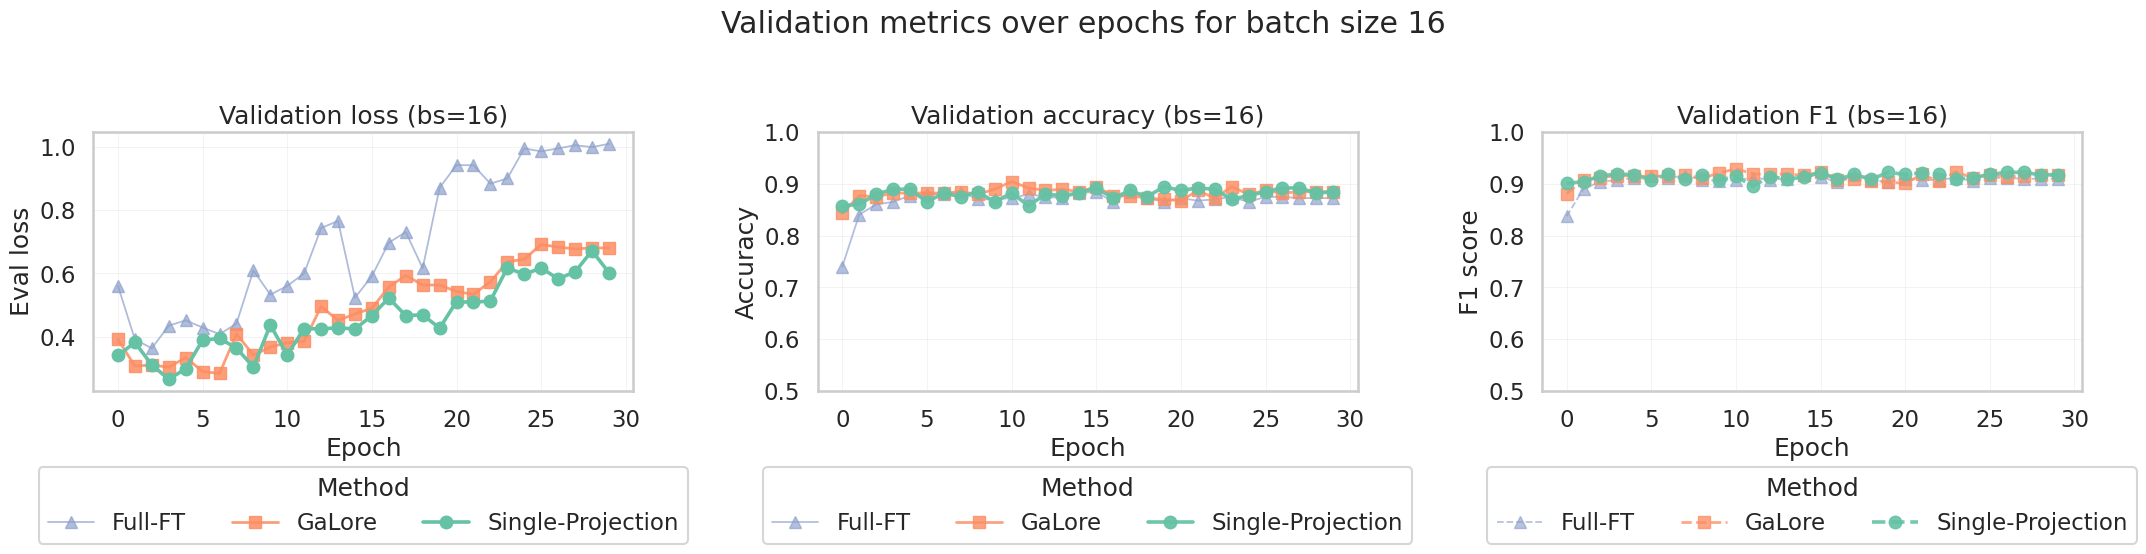

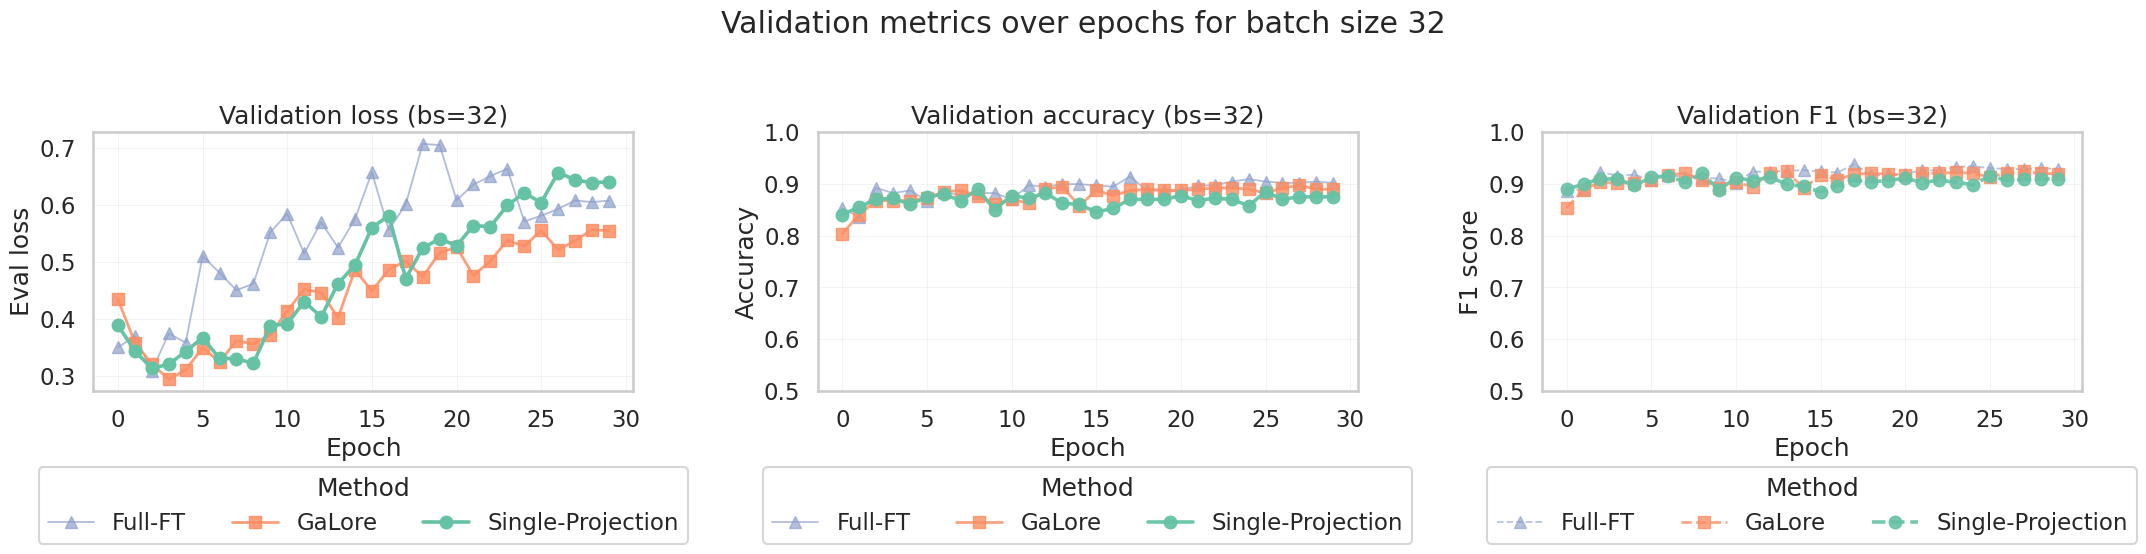

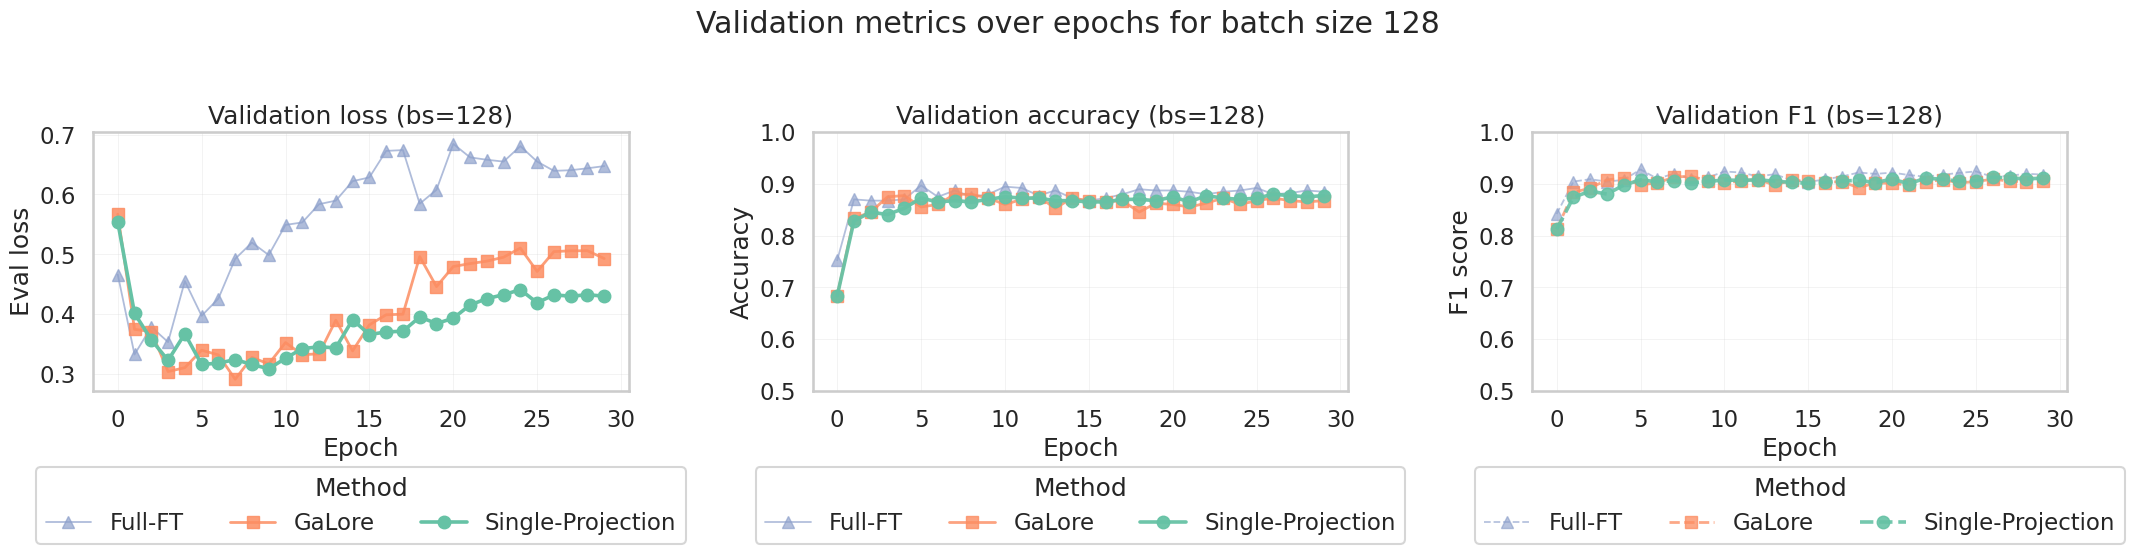

,method,batch_size,epoch,step,eval_loss,eval_accuracy,eval_f1
445,Single-Projection,128,25,754,0.418989,0.872549,0.906475
446,Single-Projection,128,26,783,0.432181,0.879902,0.912966
447,Single-Projection,128,27,812,0.430033,0.877451,0.911348
448,Single-Projection,128,28,841,0.432361,0.875000,0.909735
449,Single-Projection,128,29,870,0.430115,0.877451,0.911032


In [4]:
eval_records: List[Dict[str, Any]] = []
for spec in run_specs:
    bs = spec["batch_size"]
    method = spec["method"]
    eval_file = first_file(spec["folder"], "eval_epoch_metrics*.jsonl")
    if not eval_file:
        continue
    for row in load_jsonl(eval_file):
        eval_records.append(
            {
                "method": method,
                "batch_size": bs,
                "epoch": int(row.get("epoch", 0)),
                "step": int(row.get("step", 0)),
                "eval_loss": float(row.get("eval_loss", np.nan)),
                "eval_accuracy": float(row.get("eval_accuracy", np.nan)),
                "eval_f1": float(row.get("eval_f1", np.nan)),
            }
        )

eval_df = (
    pd.DataFrame(eval_records)
    .sort_values(["method", "batch_size", "epoch"])
    .reset_index(drop=True)
)

if eval_df.empty:
    print("No validation metrics found.")
else:
    unique_bs = sorted(eval_df["batch_size"].unique())
    methods = sorted(eval_df["method"].unique())
    method_palette = build_method_palette(methods)

    for bs in unique_bs:
        subset = eval_df[eval_df["batch_size"] == bs]
        if subset.empty:
            continue

        fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=False)
        ax_loss, ax_acc, ax_f1 = axes

        seen_loss: set[str] = set()
        for method in methods:
            method_subset = subset[subset["method"] == method]
            if method_subset.empty:
                continue
            color = method_palette[method]
            style = get_method_style(method)
            label = method if method not in seen_loss else None
            if label:
                seen_loss.add(method)
            ax_loss.plot(
                method_subset["epoch"],
                method_subset["eval_loss"],
                color=color,
                linewidth=style["linewidth"],
                alpha=style["alpha"],
                marker=style["marker"],
                label=label,
            )

        ax_loss.set_title(f"Validation loss (bs={bs})")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Eval loss")
        ax_loss.grid(True, linewidth=0.4, alpha=0.4)
        ax_loss.legend(
            title="Method",
            bbox_to_anchor=(0.5, -0.25),
            loc="upper center",
            ncol=len(methods),
        )

        seen_acc: set[str] = set()
        for method in methods:
            method_subset = subset[subset["method"] == method]
            if method_subset.empty:
                continue
            color = method_palette[method]
            style = get_method_style(method)
            curve = method_subset.dropna(subset=["eval_accuracy"])
            if curve.empty:
                continue
            label = method if method not in seen_acc else None
            if label:
                seen_acc.add(method)
            ax_acc.plot(
                curve["epoch"],
                curve["eval_accuracy"],
                color=color,
                linewidth=style["linewidth"],
                alpha=style["alpha"] * 0.95,
                linestyle="-",
                marker=style["marker"],
                label=label,
            )

        ax_acc.set_title(f"Validation accuracy (bs={bs})")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.set_ylim(0.5, 1.0)
        ax_acc.grid(True, linewidth=0.4, alpha=0.4)
        ax_acc.legend(
            title="Method",
            bbox_to_anchor=(0.5, -0.25),
            loc="upper center",
            ncol=len(methods),
        )

        seen_f1: set[str] = set()
        for method in methods:
            method_subset = subset[subset["method"] == method]
            if method_subset.empty:
                continue
            color = method_palette[method]
            style = get_method_style(method)
            curve = method_subset.dropna(subset=["eval_f1"])
            if curve.empty:
                continue
            label = method if method not in seen_f1 else None
            if label:
                seen_f1.add(method)
            ax_f1.plot(
                curve["epoch"],
                curve["eval_f1"],
                color=color,
                linewidth=style["linewidth"],
                alpha=style["alpha"] * 0.9,
                linestyle="--",
                marker=style["marker"],
                label=label,
            )

        ax_f1.set_title(f"Validation F1 (bs={bs})")
        ax_f1.set_xlabel("Epoch")
        ax_f1.set_ylabel("F1 score")
        ax_f1.set_ylim(0.5, 1.0)
        ax_f1.grid(True, linewidth=0.4, alpha=0.4)
        ax_f1.legend(
            title="Method",
            bbox_to_anchor=(0.5, -0.25),
            loc="upper center",
            ncol=len(methods),
        )

        fig.suptitle(f"Validation metrics over epochs for batch size {bs}", y=1.02)
        fig.tight_layout()
        plt.show()

    display(eval_df.tail())

## 5. Aggregate Final Eval Scores Across Batch Sizes
각 batch size별 최종 `eval_accuracy`와 `eval_f1`을 표 형태로 정리해 비교합니다.

In [5]:
if summary_df.empty:
    print("No summary metrics available.")
else:
    if eval_df.empty:
        epoch_summary = pd.DataFrame(columns=["method", "batch_size", "max_epoch"])
    else:
        epoch_summary = (
            eval_df.groupby(["method", "batch_size"])["epoch"].max().reset_index()
            .rename(columns={"epoch": "max_epoch"})
        )

    summary_table = (
        summary_df.merge(epoch_summary, how="left", on=["method", "batch_size"])
        .sort_values(["method", "batch_size"])
        .reset_index(drop=True)
)
    summary_table["max_epoch"] = summary_table["max_epoch"].astype("Int64")

    display(
        summary_table[["method", "batch_size", "max_epoch", "eval_accuracy", "eval_f1"]]
        .style.format({
            "eval_accuracy": "{:.4f}",
            "eval_f1": "{:.4f}",
        })
        .set_caption("Final evaluation metrics per batch size and method (with max epoch)")
    )

    for method, group in summary_table.groupby("method"):
        if group["eval_accuracy"].notna().any():
            best_acc = group.loc[group["eval_accuracy"].idxmax()]
            acc_msg = (
                f"Highest accuracy ({method}): batch_size={int(best_acc['batch_size'])} "
                f"({best_acc['eval_accuracy']:.4f})"
            )
        else:
            acc_msg = f"Highest accuracy ({method}): unavailable"

        if group["eval_f1"].notna().any():
            best_f1 = group.loc[group["eval_f1"].idxmax()]
            f1_msg = (
                f"Highest F1 ({method}): batch_size={int(best_f1['batch_size'])} "
                f"({best_f1['eval_f1']:.4f})"
            )
        else:
            f1_msg = f"Highest F1 ({method}): unavailable"

        print(acc_msg)
        print(f1_msg)

,method,batch_size,max_epoch,eval_accuracy,eval_f1
0,Full-FT,1,29,nan,nan
1,Full-FT,1,29,0.6838,0.8122
2,Full-FT,8,29,nan,nan
3,Full-FT,8,29,0.8750,0.9122
4,Full-FT,16,29,nan,nan
5,Full-FT,16,29,0.8725,0.9100
6,Full-FT,32,29,nan,nan
7,Full-FT,32,29,0.9020,0.9291
8,Full-FT,128,29,nan,nan
9,Full-FT,128,29,0.8848,0.9180


Highest accuracy (Full-FT): batch_size=32 (0.9020)
Highest F1 (Full-FT): batch_size=32 (0.9291)
Highest accuracy (GaLore): batch_size=32 (0.8897)
Highest F1 (GaLore): batch_size=32 (0.9198)
Highest accuracy (Single-Projection): batch_size=16 (0.8848)
Highest F1 (Single-Projection): batch_size=16 (0.9180)


## 6. Visualize Eval Accuracy and F1 Across Batch Sizes
batch size별 최종 eval accuracy / F1을 막대 그래프로 시각화하고 값 레이블을 추가합니다.

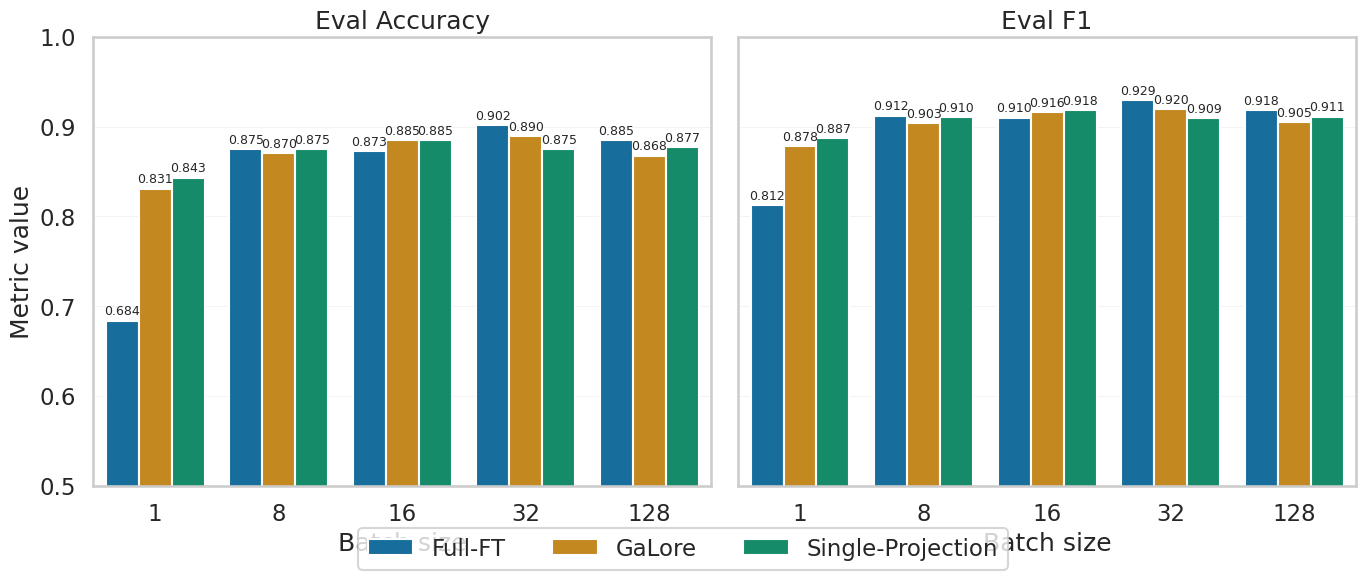

In [11]:
if summary_df.empty:
    print("No summary metrics available for visualization.")
else:
    plot_df = (
        summary_df[["method", "batch_size", "eval_accuracy", "eval_f1"]]
        .melt(id_vars=["method", "batch_size"], var_name="metric", value_name="value")
        .dropna(subset=["value"])
    )

    metrics = ["eval_accuracy", "eval_f1"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 6), sharey=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        sns.barplot(
            data=plot_df[plot_df["metric"] == metric],
            x="batch_size",
            y="value",
            hue="method",
            ax=ax,
        )
        for container in ax.containers:
            ax.bar_label(container, fmt="{:.3f}", label_type="edge", padding=2, fontsize=9)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("Batch size")
        ax.set_ylabel("Metric value")
        ax.set_ylim(0.5, 1.0)
        ax.grid(True, axis="y", linewidth=0.4, alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=len(labels))
    for ax in axes:
        leg = ax.get_legend()
        if leg:
            leg.remove()
    # fig.suptitle("Final validation accuracy vs F1 by batch size and method", y=1.02)
    fig.tight_layout()
    plt.show()

### Usage Notes
- 새로운 실험을 추가하면 각 방법 루트(`exp_outputs/mrpc_base`, `exp_outputs/mrpc_FT`, `exp_outputs/mrpc2`) 아래에 동일한 네이밍(`bs{batch}_...`)으로 저장한 뒤 1, 2번 셀만 다시 실행하면 모든 셀이 최신 데이터로 업데이트됩니다.
- 다른 작업 디렉터리에서 노트북을 실행할 경우 `resolve_experiment_roots()`의 후보 경로를 필요에 맞게 추가하거나 수정해 주세요.
- 시각화에서 single-projection을 강조하거나 baseline 대비 투명도를 조정하고 싶다면 상단의 `METHOD_STYLE`/`METHOD_ORDER` 값을 수정하면 됩니다.
- 플롯 해상도나 smoothing 스팬을 바꾸고 싶다면 2번 셀의 `get_method_style()` 혹은 `ewm_by_length` 함수를 조정하면 됩니다.